Data Loaded successfully. Cleaned 2988 valid observation rows.

  ANALYSIS: MEAN AREA RESPONSE VS DISTANCE FROM JOHNSTON'S ORGAN (JO)

--- Medial Cluster Profile (n = 19 Sensilla hairs) ---
  Raw Unweighted Pearson r : 0.130 (p = 0.5958)
  Precision Weighted Correlation r: 0.253 (accounting for sample bias)
  Linear Slope over space: 0.0575 units/μm (p = 0.2956)
  Model R-Squared: 0.064

--- Lateral Cluster Profile (n = 179 Sensilla hairs) ---
  Raw Unweighted Pearson r : 0.143 (p = 0.0558)
  Precision Weighted Correlation r: 0.114 (accounting for sample bias)
  Linear Slope over space: 0.0189 units/μm (p = 0.1292)
  Model R-Squared: 0.013


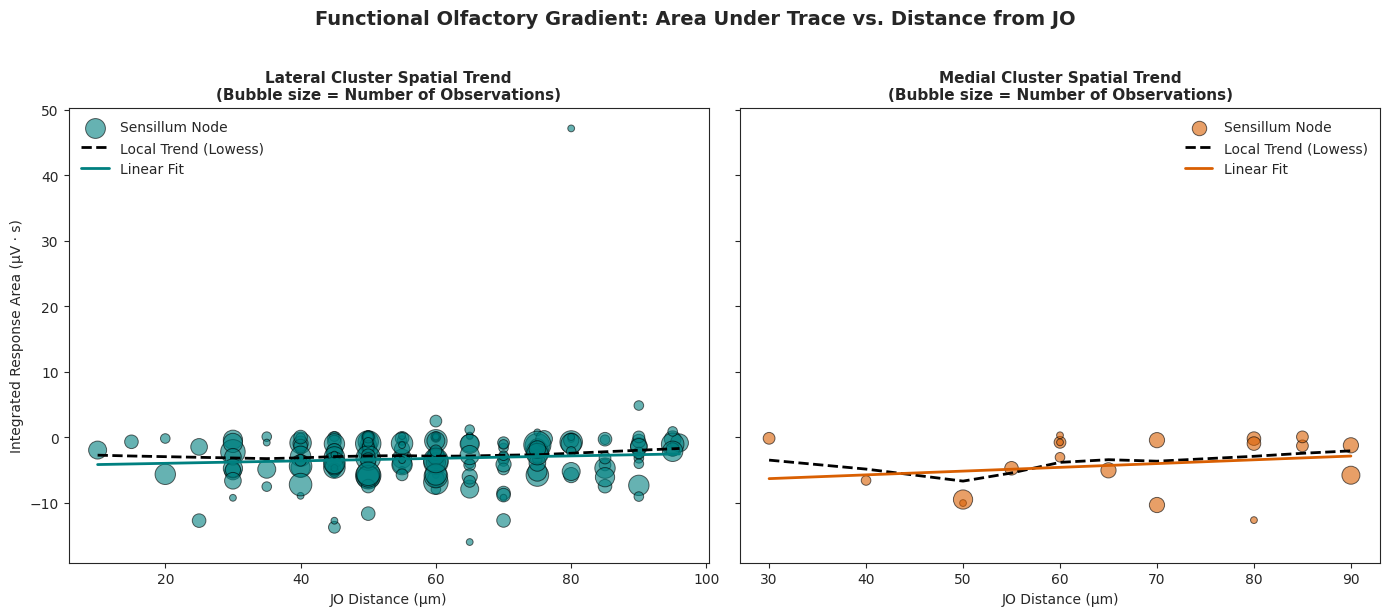


  MIXED-EFFECTS MODELING: TESTING CROSS-TALK WITH MULTIPLE BIOLOGICAL VARIABLES

[Global Mixed Model] Intersecting Spatial Gradients with Neuron Lineage:
              Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   AreaResponse
No. Observations:    2988      Method:               REML        
No. Groups:          14        Scale:                20.3419     
Min. group size:     9         Log-Likelihood:       -8773.6706  
Max. group size:     1083      Converged:            Yes         
Mean group size:     213.4                                       
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept              -4.598    0.800 -5.745 0.000 -6.167 -3.029
Cell[T.CpB]             0.000    0.664  0.000 1.000 -1.301  1.301
Cell[T.CpC]             0.000    0.664  0.000 1.000 -1.301  1.301
C

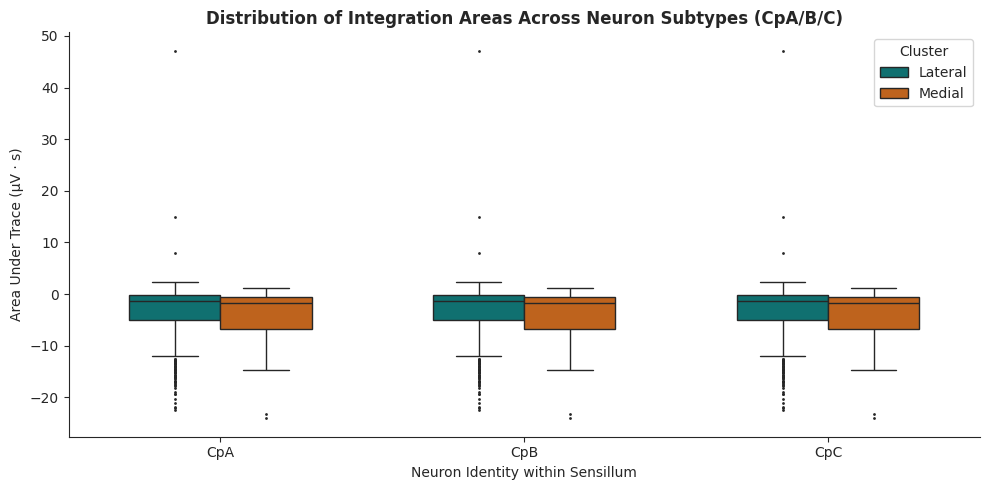


Tidy datasets written safely to disks: 'sensilla_long_tidy.csv' & 'sensillum_level_summary.csv'


In [ ]:
# =============================================================
# Mosquito Maxillary Palp Sensilla — JO Distance vs Area Response
# =============================================================
# Optimized specifically for analyzing Area under the curve metrics.
# Paste this into a Colab cell.
# =============================================================

!pip install -q statsmodels openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

sns.set_style("ticks")
plt.rcParams['svg.fonttype'] = 'none' # For clean vector graphic exports

# -------------------------------------------------------------
# 1. LOAD & PREPARE DATA
# -------------------------------------------------------------
# -------------------------------------------------------------
# 1. LOAD & PREPARE DATA
# -------------------------------------------------------------
FILE_PATH = "Sensilla_Average_Area_Summary.xlsx"  ### Make sure this matches your exact filename

# Use read_excel instead of read_csv for actual .xlsx files
df = pd.read_excel(FILE_PATH, header=0)

meta_cols = ["Strain", "Brain", "Palp", "Sensilla", "Location", "JODistance", "ElectrodeLocation"]
response_cols = [c for c in df.columns if c not in meta_cols]

# Melt long format (one row per observation)
long_df = df.melt(id_vars=meta_cols, value_vars=response_cols,
                  var_name="RawCol", value_name="AreaResponse")

# Extract Cell (CpA/B/C) and Odor name
long_df["Cell"] = long_df["RawCol"].str.extract(r"_(Cp[ABC])$")
long_df["Odour"] = long_df["RawCol"].str.replace(r"_Cp[ABC]$", "", regex=True)
long_df = long_df.drop(columns="RawCol").dropna(subset=["AreaResponse"])

# Assign Clusters (Medial vs Lateral)
def assign_cluster(loc):
    if pd.isna(loc): return np.nan
    loc = str(loc)
    if "Medial" in loc: return "Medial"
    elif "Lateral" in loc: return "Lateral"
    return np.nan

long_df["Cluster"] = long_df["Location"].apply(assign_cluster)

# Filter down to entries that can actually be mapped spatially
analysis_df = long_df.dropna(subset=["JODistance", "AreaResponse", "Cluster"]).copy()
analysis_df["Strain"] = analysis_df["Strain"].astype(str).str.strip()

# Unique identifier per sensillum hair
analysis_df["SensillumID"] = (analysis_df["Strain"] + "|" +
                               analysis_df["Brain"].astype(str) + "|" +
                               analysis_df["Palp"].astype(str) + "|" +
                               analysis_df["Sensilla"].astype(str))

print(f"Data Loaded successfully. Cleaned {analysis_df.shape[0]} valid observation rows.")

# -------------------------------------------------------------
# 2. SENSILLUM-LEVEL AGGREGATION & PRECISION WEIGHTING
# -------------------------------------------------------------
# Collapsing multiple trials into a single physical sensillum node to relate
# directly to structural anatomy (JODistance), using total recording size as weight.
sensillum_summary = (
    analysis_df.groupby(["SensillumID", "Strain", "Cluster", "JODistance", "ElectrodeLocation"],
                         dropna=False, as_index=False)
    .agg(AvgArea=("AreaResponse", "mean"),
         MedArea=("AreaResponse", "median"), # Median limits effect of outlier explosive bursts
         NReadings=("AreaResponse", "size"))
)

# Custom weighted Pearson function
def weighted_pearson(x, y, w):
    mx, my = np.average(x, weights=w), np.average(y, weights=w)
    cxy = np.average((x - mx) * (y - my), weights=w)
    cxx = np.average((x - mx) ** 2, weights=w)
    cyy = np.average((y - my) ** 2, weights=w)
    return cxy / np.sqrt(cxx * cyy)

# -------------------------------------------------------------
# 3. CORE COGNITIVE FOCUS: AREA VS JO DISTANCE STATS
# -------------------------------------------------------------
print("\n" + "="*75)
print("  ANALYSIS: MEAN AREA RESPONSE VS DISTANCE FROM JOHNSTON'S ORGAN (JO)")
print("="*75)

for cluster in ["Medial", "Lateral"]:
    sub = sensillum_summary[sensillum_summary["Cluster"] == cluster]
    if len(sub) < 5:
        print(f"\nCluster '{cluster}' lacks sufficient sensilla sample points.")
        continue

    r_unw, p_unw = stats.pearsonr(sub["JODistance"], sub["AvgArea"])
    r_w = weighted_pearson(sub["JODistance"], sub["AvgArea"], sub["NReadings"])

    print(f"\n--- {cluster} Cluster Profile (n = {len(sub)} Sensilla hairs) ---")
    print(f"  Raw Unweighted Pearson r : {r_unw:.3f} (p = {p_unw:.4f})")
    print(f"  Precision Weighted Correlation r: {r_w:.3f} (accounting for sample bias)")

    # Weighted Least Squares modeling
    try:
        wls_mod = smf.wls("AvgArea ~ JODistance", data=sub, weights=sub["NReadings"]).fit()
        print(f"  Linear Slope over space: {wls_mod.params['JODistance']:.4f} units/μm (p = {wls_mod.pvalues['JODistance']:.4f})")
        print(f"  Model R-Squared: {wls_mod.rsquared:.3f}")
    except Exception as e:
        print(f"  Regression fit error: {e}")

# -------------------------------------------------------------
# 4. TAILORED PLOTTING: SPATIAL GRADIENTS
# -------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, cluster, color in zip(axes, ["Lateral", "Medial"], ["#008080", "#D95F02"]):
    sub = sensillum_summary[sensillum_summary["Cluster"] == cluster]

    # Bubble plot where dot volume scales with precision level (# of recordings taken)
    scatter = ax.scatter(sub["JODistance"], sub["AvgArea"],
                         s=sub["NReadings"] * 8, alpha=0.6,
                         color=color, edgecolor='k', linewidth=0.7, label='Sensillum Node')

    # Avoid forcing a straight line if biology is curved: fit a non-parametric LOWESS curve
    if len(sub) > 5:
        lowess = sm.nonparametric.lowess(sub["AvgArea"], sub["JODistance"], frac=0.6)
        ax.plot(lowess[:, 0], lowess[:, 1], color='black', linestyle='--', linewidth=2, label='Local Trend (Lowess)')

        # Overlay WLS Linear Trend
        wls_mod = smf.wls("AvgArea ~ JODistance", data=sub, weights=sub["NReadings"]).fit()
        xs = np.linspace(sub["JODistance"].min(), sub["JODistance"].max(), 100)
        pred = wls_mod.predict(pd.DataFrame({"JODistance": xs}))
        ax.plot(xs, pred, color=color, linewidth=2, label='Linear Fit')

    ax.set_title(f"{cluster} Cluster Spatial Trend\n(Bubble size = Number of Observations)", fontsize=11, weight='bold')
    ax.set_xlabel("JO Distance (μm)", fontsize=10)
    ax.legend(frameon=True, facecolor='white', edgecolor='none')

axes[0].set_ylabel("Integrated Response Area (μV · s)", fontsize=10)
plt.suptitle("Functional Olfactory Gradient: Area Under Trace vs. Distance from JO", y=1.02, fontsize=14, weight='semibold')
plt.tight_layout()
plt.savefig("Area_vs_JODistance_Spatial_Gradient.png", dpi=300, bbox_inches='tight')
plt.show()

# -------------------------------------------------------------
# 5. MIXED-EFFECTS MODELS: INTERACTION TESTING
# -------------------------------------------------------------
print("\n" + "="*75)
print("  MIXED-EFFECTS MODELING: TESTING CROSS-TALK WITH MULTIPLE BIOLOGICAL VARIABLES")
print("="*75)

# Checking if the spatial layout acts differently for the three specialized neuron lines (CpA, CpB, CpC)
try:
    print("\n[Global Mixed Model] Intersecting Spatial Gradients with Neuron Lineage:")
    global_model = smf.mixedlm("AreaResponse ~ JODistance * Cell + Cluster",
                               data=analysis_df, groups=analysis_df["Strain"])
    global_res = global_model.fit(reml=True)
    print(global_res.summary())
except Exception as e:
    print(f"Complex model failed convergence: {e}")

# -------------------------------------------------------------
# 6. SECONDARY INSIGHT: NEURON FUNCTIONAL SUB-TYPES BY CLUSTER
# -------------------------------------------------------------
# Area responses track physical limits of unique sensory units. Let's see how much
# CpA, CpB, or CpC govern overall cluster properties.
plt.figure(figsize=(10, 5))
sns.boxplot(data=analysis_df, x="Cell", y="AreaResponse", hue="Cluster",
            palette=["#008080", "#D95F02"], fliersize=1, width=0.6)
plt.title("Distribution of Integration Areas Across Neuron Subtypes (CpA/B/C)", fontsize=12, weight='bold')
plt.xlabel("Neuron Identity within Sensillum")
plt.ylabel("Area Under Trace (μV · s)")
sns.despine()
plt.tight_layout()
plt.savefig("Area_Distribution_By_Cell_Type.png", dpi=300)
plt.show()

print("\nTidy datasets written safely to disks: 'sensilla_long_tidy.csv' & 'sensillum_level_summary.csv'")

Raw Matrix Shape: (302, 142)
Total Area Response Columns Found: 135
Tidy Long-Format Shape (Non-empty readings only): (4248, 10)
Filtered rows usable for spatial mapping: 2988

  PHASE 4: SPATIAL ANALYSIS — DRIVING INTEGRATION AREA BY JO DISTANCE

>>> Medial Cluster Metrics (n = 19 Sensilla Hairs) <<<
  Unweighted Pearson r = 0.130, p = 0.5958
  Weighted Pearson r   = 0.253 (Accounting for observation density bias)

  Weighted Least Squares (WLS) Linear Fit Summary:
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -8.0749      3.763     -2.146      0.047     -16.015      -0.135
JODistance     0.0575      0.053      1.079      0.296      -0.055       0.170

>>> Lateral Cluster Metrics (n = 179 Sensilla Hairs) <<<
  Unweighted Pearson r = 0.143, p = 0.0558
  Weighted Pearson r   = 0.114 (Accounting for observation density bias)

  Weighted Least Squares (WLS) Linear 

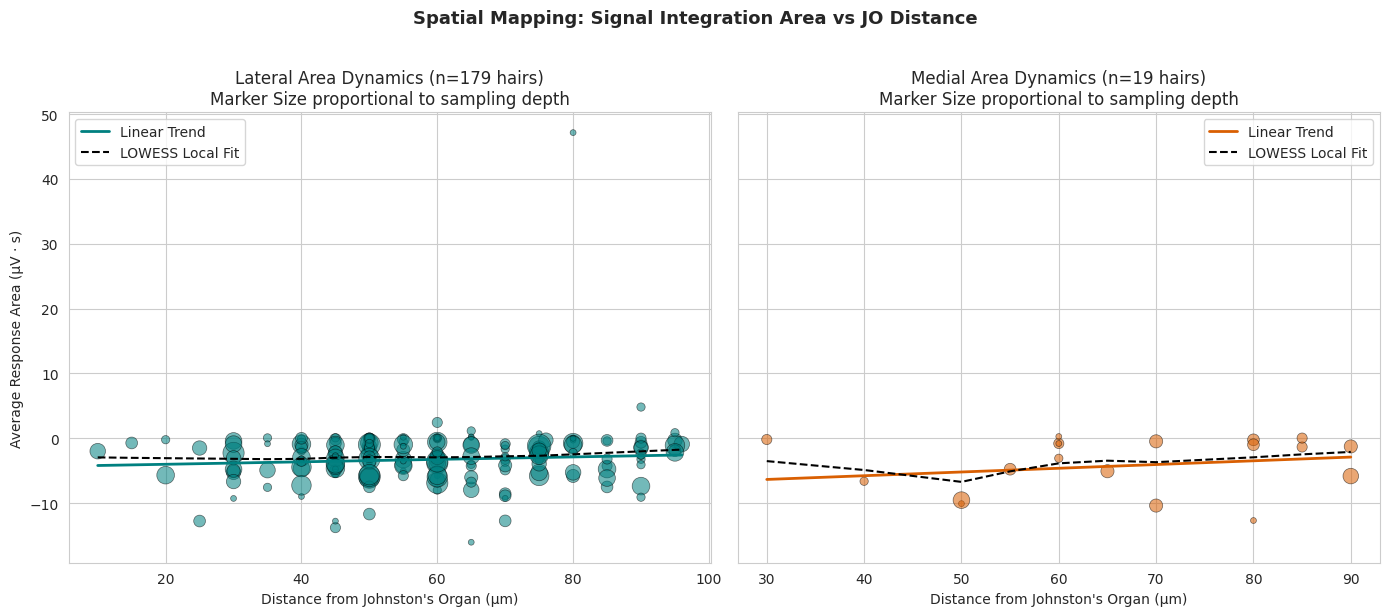


  PHASE 4b: SIGNAL INTEGRATION AREA VS ELECTRODE POSITION

Medial Position Profile:
  Weighted Electrode Coordinate vs Area Response r = 0.249
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -8.1419      7.283     -1.118      0.306     -25.963       9.680
ElectrodeLocation     0.0713      0.114      0.628      0.553      -0.206       0.349

Lateral Position Profile:
  Weighted Electrode Coordinate vs Area Response r = -0.022
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -2.8286      0.920     -3.074      0.003      -4.657      -1.000
ElectrodeLocation    -0.0032      0.016     -0.205      0.838      -0.034       0.028


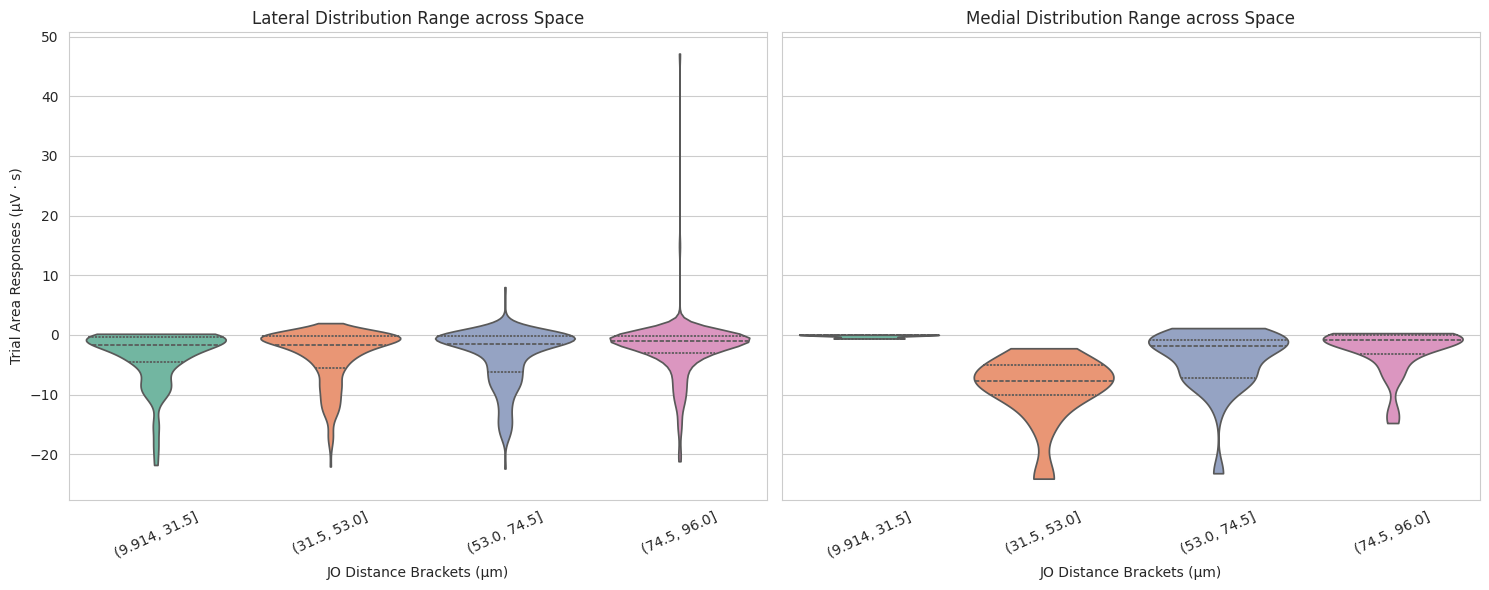


  PHASE 5: MIXED-EFFECTS MODELING — CONTROLLING VARIANCE STRUCTURES

[Mixed Model] Medial Cluster: Area ~ Spatial Placement + Cell Pedigree (Random Slopes: Strain)
              Coef. Std.Err.       z  P>|z|  [0.025  0.975]
Intercept    -4.243    1.911  -2.220  0.026  -7.989  -0.496
Cell[T.CpB]  -0.000    0.719  -0.000  1.000  -1.409   1.409
Cell[T.CpC]  -0.000    0.719  -0.000  1.000  -1.409   1.409
JODistance    0.031    0.024   1.322  0.186  -0.015   0.077
Group Var     6.579    0.932                               

[Mixed Model] Lateral Cluster: Area ~ Spatial Placement + Cell Pedigree (Random Slopes: Strain)
              Coef. Std.Err.       z  P>|z|  [0.025  0.975]
Intercept    -4.751    0.734  -6.473  0.000  -6.190  -3.313
Cell[T.CpB]  -0.000    0.209  -0.000  1.000  -0.410   0.410
Cell[T.CpC]  -0.000    0.209  -0.000  1.000  -0.410   0.410
JODistance    0.033    0.005   6.713  0.000   0.023   0.043
Group Var     5.456    0.526                               

[Interaction Assa

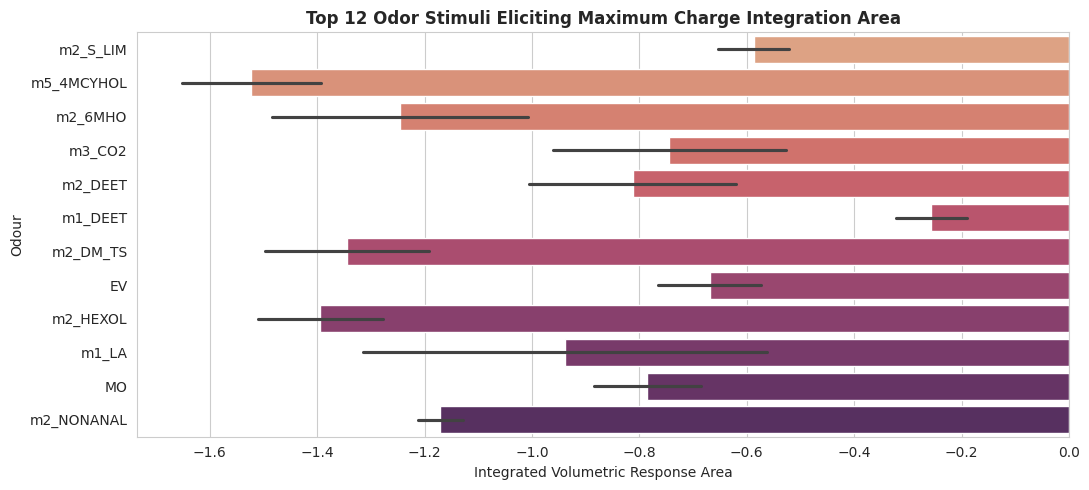


Lineage Specific Integration Capacity Matrix:
                  mean       std  count
Cluster Cell                           
Lateral CpA  -3.287201  4.809543    929
        CpB  -3.287201  4.809543    929
        CpC  -3.287201  4.809543    929
Medial  CpA  -4.130178  5.210967     67
        CpB  -4.130178  5.210967     67
        CpC  -4.130178  5.210967     67


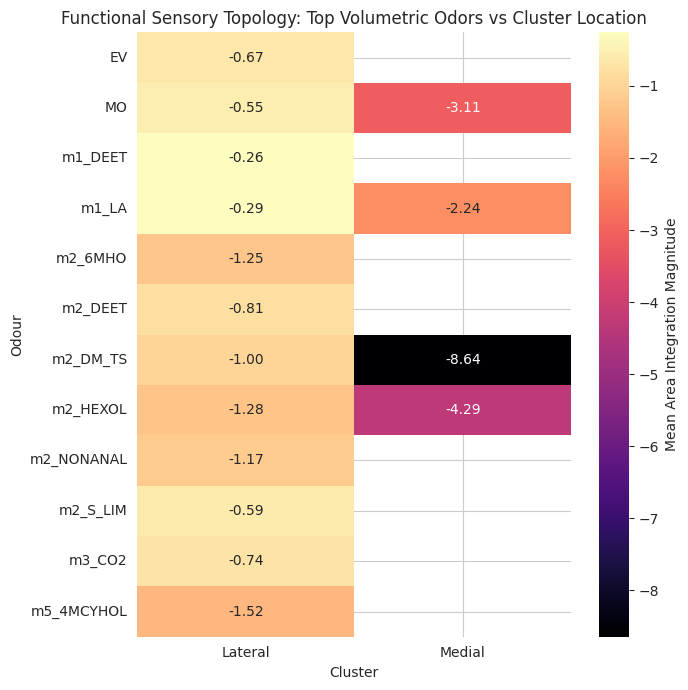


Execution Finalized successfully. Clean structural output catalogs generated.


In [ ]:
# ==============================================================================
# Mosquito Maxillary Palp Sensilla — JO Distance vs Area Deep Dive Analysis
# ==============================================================================
# Paste this entire script into your Colab cell.
# ==============================================================================

!pip install -q statsmodels openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)

# ----------------------------------------------------------------
# 1. LOAD & RESHAPE DATA (BINARY EXCEL COMPATIBLE)
# ----------------------------------------------------------------
FILE_PATH = "Sensilla_Average_Area_Summary.xlsx"  ### CHANGE ME if filename differs

try:
    df = pd.read_excel(FILE_PATH, header=0)
except Exception:
    # Fallback to CSV if you pre-converted it in Colab
    df = pd.read_csv("Sensilla_Average_Area_Summary.xlsx - Average_Area.csv", header=0)

meta_cols = ["Strain", "Brain", "Palp", "Sensilla", "Location", "JODistance", "ElectrodeLocation"]
all_response_cols = [c for c in df.columns if c not in meta_cols]

print(f"Raw Matrix Shape: {df.shape}")
print(f"Total Area Response Columns Found: {len(all_response_cols)}")

# Melt wide-format Excel to tidy long-format
long_df = df.melt(id_vars=meta_cols, value_vars=all_response_cols,
                  var_name="RawCol", value_name="AreaResponse")

# Extract neural components specific to capitate-peg sensilla (CpA, CpB, CpC)
long_df["Cell"] = long_df["RawCol"].str.extract(r"_(Cp[ABC])$")
long_df["Odour"] = long_df["RawCol"].str.replace(r"_Cp[ABC]$", "", regex=True)
long_df = long_df.drop(columns="RawCol")

# Drop completely empty/unrecorded spaces in the matrix
long_df = long_df.dropna(subset=["AreaResponse"])

print(f"Tidy Long-Format Shape (Non-empty readings only): {long_df.shape}")

# ----------------------------------------------------------------
# 2. ANATOMICAL CLUSTERING & SPATIAL FILTERS
# ----------------------------------------------------------------
def assign_cluster(loc):
    if pd.isna(loc): return np.nan
    loc = str(loc)
    if "Medial" in loc: return "Medial"
    elif "Lateral" in loc: return "Lateral"
    return np.nan

long_df["Cluster"] = long_df["Location"].apply(assign_cluster)

# Filter down to rows explicitly containing spatial metrics
analysis_df = long_df.dropna(subset=["JODistance", "AreaResponse", "Cluster"]).copy()
analysis_df["Strain"] = analysis_df["Strain"].astype(str).str.strip()

# Generate globally unique tracking tags for each sensory hair structure
analysis_df["SensillumID"] = (analysis_df["Strain"] + "|" +
                               analysis_df["Brain"].astype(str) + "|" +
                               analysis_df["Palp"].astype(str) + "|" +
                               analysis_df["Sensilla"].astype(str))

# Export long format data for custom external workflows
analysis_df.to_csv("area_sensilla_long_tidy.csv", index=False)
print(f"Filtered rows usable for spatial mapping: {analysis_df.shape[0]}")

# ----------------------------------------------------------------
# 3. SENSILLUM-LEVEL PRECISION WEIGHTING DATASET
# ----------------------------------------------------------------
# Since spatial properties (JODistance) belong to the hair structure rather than the
# individual puff trial, we collapse readings to single sensillum nodes, tracking sample depth.
sensillum_summary = (
    analysis_df.groupby(["SensillumID", "Strain", "Cluster", "JODistance", "ElectrodeLocation"],
                         dropna=False, as_index=False)
    .agg(AvgArea=("AreaResponse", "mean"),
         NReadings=("AreaResponse", "size"))
)
sensillum_summary.to_csv("area_sensillum_level_summary.csv", index=False)

def weighted_pearson(x, y, w):
    """Analytic Weighted Pearson Correlation."""
    x, y, w = np.asarray(x, float), np.asarray(y, float), np.asarray(w, float)
    mx, my = np.average(x, weights=w), np.average(y, weights=w)
    cxy = np.average((x - mx) * (y - my), weights=w)
    cxx = np.average((x - mx) ** 2, weights=w)
    cyy = np.average((y - my) ** 2, weights=w)
    return cxy / np.sqrt(cxx * cyy)

# ==============================================================================
# 4. PRIMARY ANALYTICAL QUESTION: RIGOROUS SPATIAL MODELING
# ==============================================================================
print("\n" + "="*80)
print("  PHASE 4: SPATIAL ANALYSIS — DRIVING INTEGRATION AREA BY JO DISTANCE")
print("="*80)

for cluster in ["Medial", "Lateral"]:
    sub = sensillum_summary[sensillum_summary["Cluster"] == cluster]
    if len(sub) < 4:
        print(f"\nSkipping {cluster} spatial regression due to limited sample points.")
        continue

    r_unw, p_unw = stats.pearsonr(sub["JODistance"], sub["AvgArea"])
    r_w = weighted_pearson(sub["JODistance"], sub["AvgArea"], sub["NReadings"])

    print(f"\n>>> {cluster} Cluster Metrics (n = {len(sub)} Sensilla Hairs) <<<")
    print(f"  Unweighted Pearson r = {r_unw:.3f}, p = {p_unw:.4f}")
    print(f"  Weighted Pearson r   = {r_w:.3f} (Accounting for observation density bias)")

    try:
        wls_model = smf.wls("AvgArea ~ JODistance", data=sub, weights=sub["NReadings"]).fit()
        print("\n  Weighted Least Squares (WLS) Linear Fit Summary:")
        print(wls_model.summary().tables[1])
    except Exception as e:
        print(f"  WLS Regression failed to compute: {e}")

# Visualization: Weighted Bubble Scatter Matrix + Trendline Fits
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for ax, cluster, color in zip(axes, ["Lateral", "Medial"], ["#008080", "#D95F02"]):
    sub = sensillum_summary[sensillum_summary["Cluster"] == cluster]
    ax.scatter(sub["JODistance"], sub["AvgArea"],
               s=sub["NReadings"] * 6, alpha=0.55, color=color,
               edgecolor="black", linewidth=0.5)

    if len(sub) >= 4:
        # Overlay standard WLS Line
        wls_model = smf.wls("AvgArea ~ JODistance", data=sub, weights=sub["NReadings"]).fit()
        xs = np.linspace(sub["JODistance"].min(), sub["JODistance"].max(), 100)
        pred = wls_model.predict(pd.DataFrame({"JODistance": xs}))
        ax.plot(xs, pred, color=color, linewidth=2, label="Linear Trend")

        # Overlay Lowess curve to reveal non-linear anatomical thresholds
        lowess = sm.nonparametric.lowess(sub["AvgArea"], sub["JODistance"], frac=0.65)
        ax.plot(lowess[:, 0], lowess[:, 1], color="black", linestyle="--", linewidth=1.5, label="LOWESS Local Fit")

    ax.set_title(f"{cluster} Area Dynamics (n={len(sub)} hairs)\nMarker Size proportional to sampling depth")
    ax.set_xlabel("Distance from Johnston's Organ (μm)")
    ax.legend(frameon=True)

axes[0].set_ylabel("Average Response Area (μV · s)")
fig.suptitle("Spatial Mapping: Signal Integration Area vs JO Distance", y=1.02, fontsize=13, weight='bold')
plt.tight_layout()
plt.savefig("area_analysis_jodistance_weighted.png", dpi=150, bbox_inches="tight")
plt.show()

# ----------------------------------------------------------------
# 4b. SECONDARY SPATIAL PROPERTY: RECEPTOR AREA VS ELECTRODE LOCATION
# ----------------------------------------------------------------
print("\n" + "="*80)
print("  PHASE 4b: SIGNAL INTEGRATION AREA VS ELECTRODE POSITION")
print("="*80)

el_summary = sensillum_summary.dropna(subset=["ElectrodeLocation"])
for cluster in ["Medial", "Lateral"]:
    sub = el_summary[el_summary["Cluster"] == cluster]
    if len(sub) < 4: continue

    r_w = weighted_pearson(sub["ElectrodeLocation"], sub["AvgArea"], sub["NReadings"])
    print(f"\n{cluster} Position Profile:")
    print(f"  Weighted Electrode Coordinate vs Area Response r = {r_w:.3f}")
    try:
        wls_el = smf.wls("AvgArea ~ ElectrodeLocation", data=sub, weights=sub["NReadings"]).fit()
        print(wls_el.summary().tables[1])
    except Exception as e: print(f"WLS execution error: {e}")

# ----------------------------------------------------------------
# 4c. COARSE REPEATED OBSERVATION DISTRIBUTIONS (VIOLIN QUANTILES)
# ----------------------------------------------------------------
analysis_df["JODistanceBin"] = pd.cut(analysis_df["JODistance"], bins=4)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
for ax, cluster in zip(axes, ["Lateral", "Medial"]):
    sub = analysis_df[analysis_df["Cluster"] == cluster]
    sns.violinplot(data=sub, x="JODistanceBin", y="AreaResponse",
                   ax=ax, cut=0, inner="quartile", palette="Set2")
    ax.set_title(f"{cluster} Distribution Range across Space")
    ax.set_xlabel("JO Distance Brackets (μm)")
    ax.tick_params(axis="x", rotation=25)
axes[0].set_ylabel("Trial Area Responses (μV · s)")
plt.tight_layout()
plt.savefig("area_distribution_bins.png", dpi=150)
plt.show()

# ==============================================================================
# 5. ADVANCED QUANTITATIVE INFERENCE: MIXED-EFFECTS MODELS
# ==============================================================================
print("\n" + "="*80)
print("  PHASE 5: MIXED-EFFECTS MODELING — CONTROLLING VARIANCE STRUCTURES")
print("="*80)

for cluster in ["Medial", "Lateral"]:
    sub = analysis_df[analysis_df["Cluster"] == cluster].copy()
    if sub["Strain"].nunique() < 2 or len(sub) < 15:
        print(f"\nSkipping advanced mixed model modeling for {cluster} (Insufficient grouping fields).")
        continue

    print(f"\n[Mixed Model] {cluster} Cluster: Area ~ Spatial Placement + Cell Pedigree (Random Slopes: Strain)")
    try:
        # Modeling fixed parameters of location and genetic sub-cell lineage against random variance of mosquito strains
        model = smf.mixedlm("AreaResponse ~ JODistance + Cell", data=sub, groups=sub["Strain"])
        print(model.fit(reml=True).summary().tables[1])
    except Exception as e: print(f"Convergence Interrupted: {e}")

print("\n[Interaction Assay] Evaluating if Spatial Gradients diverge structurally between Medial & Lateral Profiles:")
try:
    inter_model = smf.mixedlm("AreaResponse ~ JODistance * Cluster", data=analysis_df, groups=analysis_df["Strain"])
    print(inter_model.fit(reml=True).summary())
except Exception as e: print(f"Interaction Model execution failure: {e}")

# ==============================================================================
# 6. SECONDARY MULTI-DIMENSIONAL SCREENING
# ==============================================================================
print("\n" + "="*80)
print("  PHASE 6: RECEPTOR DYNAMICS SCREENING (STRAIN, CELL TYPE, ODOR SPECTRUM)")
print("="*80)

# --- 6a. Genetic Divergence Profile (Strain Metrics) ---
strain_summary = analysis_df.groupby("Strain")["AreaResponse"].agg(["mean", "std", "count"]).sort_values("count", ascending=False)
print("\nTop Evaluated Mosquito Strain Lineages:")
print(strain_summary.head(8))

# --- 6b. Functional Odor Characterization ---
odour_summary = analysis_df.groupby("Odour")["AreaResponse"].agg(["mean", "std", "count"])
top_odours = odour_summary[odour_summary["count"] >= 5].sort_values("mean", ascending=False).head(12).index

plt.figure(figsize=(11, 5))
sns.barplot(data=analysis_df[analysis_df["Odour"].isin(top_odours)], y="Odour", x="AreaResponse", errorbar="se", palette="flare")
plt.title("Top 12 Odor Stimuli Eliciting Maximum Charge Integration Area", weight='bold')
plt.xlabel("Integrated Volumetric Response Area")
plt.tight_layout()
plt.savefig("area_top_odors_profile.png", dpi=150)
plt.show()

# --- 6c. Functional Lineage Profiles (CpA, B, C Sub-units) ---
print("\nLineage Specific Integration Capacity Matrix:")
print(analysis_df.groupby(["Cluster", "Cell"])["AreaResponse"].agg(["mean", "std", "count"]))

# --- 6d. Cross Examination Heatmaps: Spatial Clustering vs Odor Tuning Profiles ---
pivot = analysis_df[analysis_df["Odour"].isin(top_odours)].groupby(["Odour", "Cluster"])["AreaResponse"].mean().unstack()
plt.figure(figsize=(7, 7))
sns.heatmap(pivot, cmap="magma", annot=True, fmt=".2f", cbar_kws={'label': 'Mean Area Integration Magnitude'})
plt.title("Functional Sensory Topology: Top Volumetric Odors vs Cluster Location")
plt.tight_layout()
plt.savefig("area_odor_cluster_interaction_heatmap.png", dpi=150)
plt.show()

print("\n" + "="*80)
print("Execution Finalized successfully. Clean structural output catalogs generated.")
print("="*80)

Raw Matrix Shape: (302, 142)
Total Area Columns Found: 135
Tidy Long-Format Shape (Recorded responses only): (4248, 10)
Filtered rows usable for spatial mapping (JO or Electrode): 3504

  PHASE 4: SPATIAL MAPPING — DRIVING INTEGRATION AREA BY JO DISTANCE

>>> Medial Cluster JO Profile (n = 19 Sensilla Hairs) <<<
  Unweighted Pearson r = 0.130, p = 0.5958
  Precision Weighted r = 0.253 (Correcting for sample volume bias)

  Weighted Least Squares (WLS) Linear Fit Summary Table:
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -8.0749      3.763     -2.146      0.047     -16.015      -0.135
JODistance     0.0575      0.053      1.079      0.296      -0.055       0.170

>>> Lateral Cluster JO Profile (n = 179 Sensilla Hairs) <<<
  Unweighted Pearson r = 0.143, p = 0.0558
  Precision Weighted r = 0.114 (Correcting for sample volume bias)

  Weighted Least Squares (WLS)

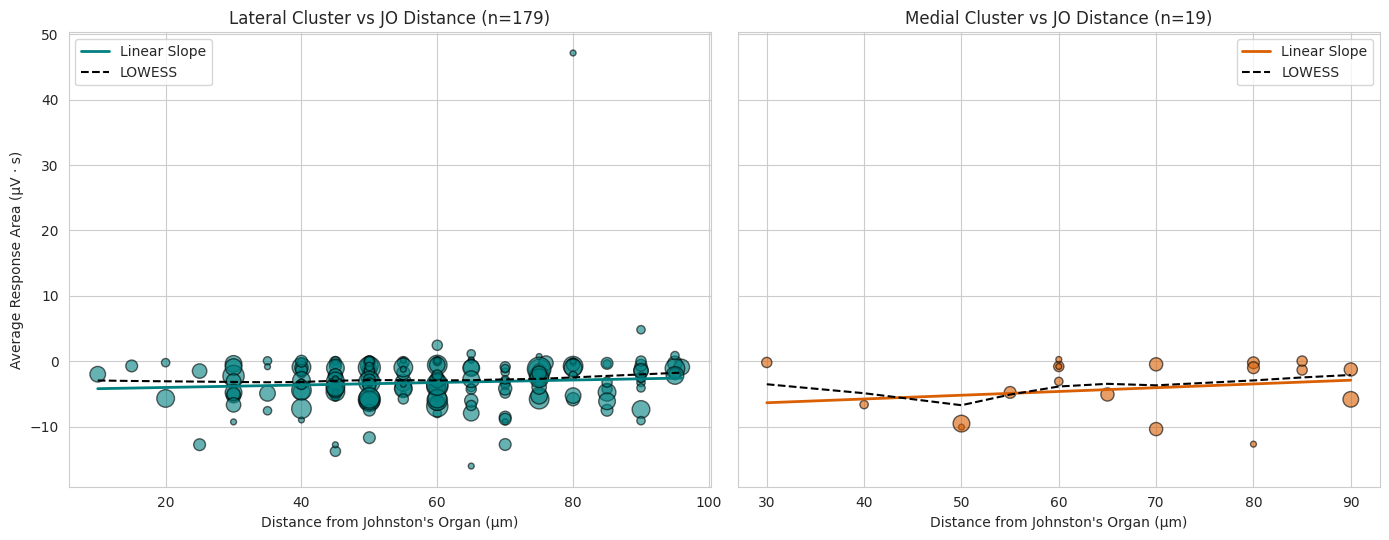


  PHASE 4b: INTEGRATED AREA RESPONSE VS ELECTRODE LOCATION COORDINATES

>>> Medial Coordinates Vector Evaluation (n = 25 Sensilla Hairs) <<<
  Unweighted Pearson r = 0.153, p = 0.4665
  Precision Weighted r = -0.095 (Correcting for sample volume bias)

  Weighted Least Squares (WLS) Linear Fit Summary Table:
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -1.2328      5.658     -0.218      0.829     -12.937      10.472
ElectrodeLocation    -0.0401      0.088     -0.458      0.651      -0.221       0.141

>>> Lateral Coordinates Vector Evaluation (n = 115 Sensilla Hairs) <<<
  Unweighted Pearson r = 0.059, p = 0.5325
  Precision Weighted r = -0.013 (Correcting for sample volume bias)

  Weighted Least Squares (WLS) Linear Fit Summary Table:
                        coef    std err          t      P>|t|      [0.025      0.975]
------------------

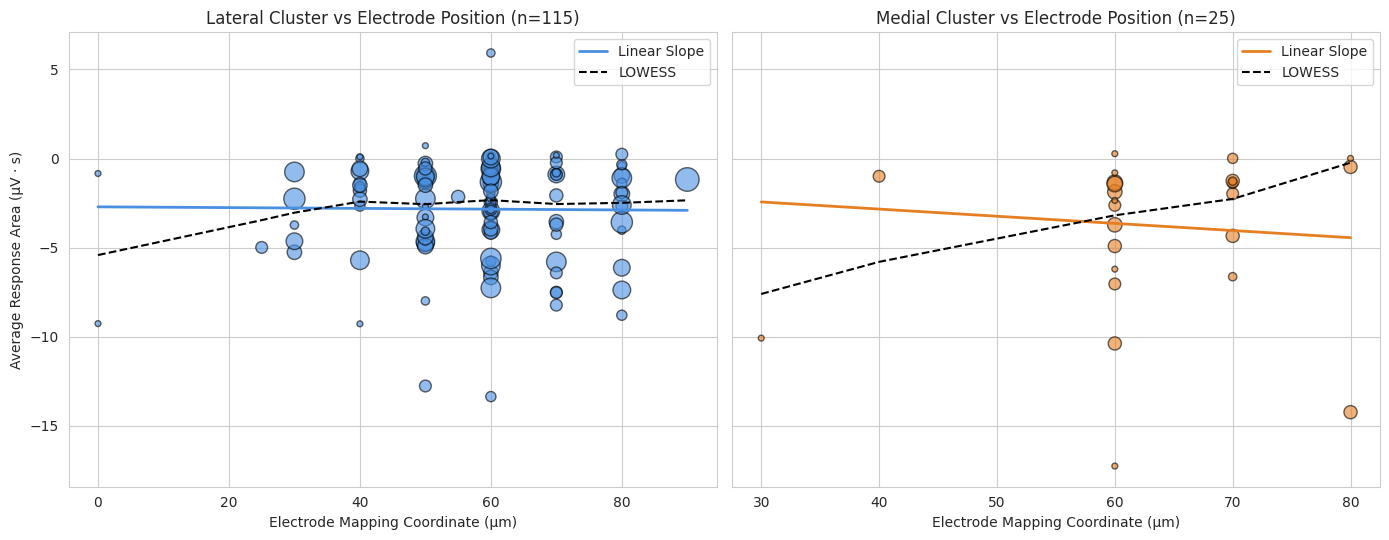

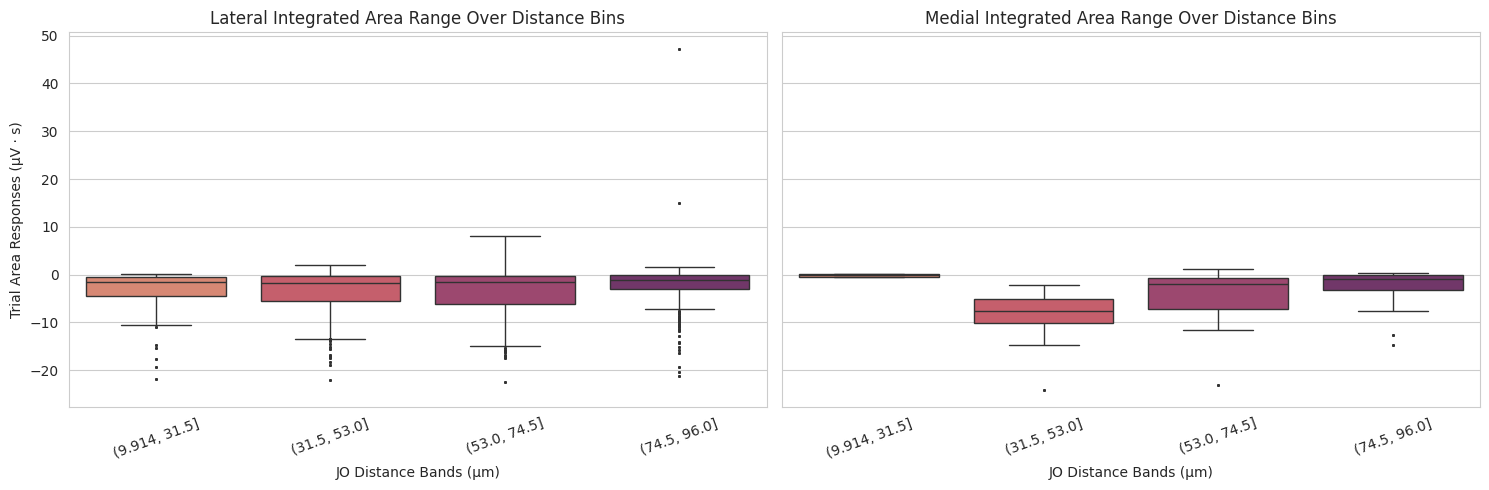


  PHASE 5: INDUCTIVE COVARIANCES — LINEAR MIXED MODELS

[LMM Output] Medial Array: Area ~ JODistance + Cell Lineage (Random Intercepts: Strain)
              Coef. Std.Err.       z  P>|z|  [0.025  0.975]
Intercept    -4.243    1.911  -2.220  0.026  -7.989  -0.496
Cell[T.CpB]  -0.000    0.719  -0.000  1.000  -1.409   1.409
Cell[T.CpC]  -0.000    0.719  -0.000  1.000  -1.409   1.409
JODistance    0.031    0.024   1.322  0.186  -0.015   0.077
Group Var     6.579    0.932                               

[LMM Output] Lateral Array: Area ~ JODistance + Cell Lineage (Random Intercepts: Strain)
              Coef. Std.Err.       z  P>|z|  [0.025  0.975]
Intercept    -4.751    0.734  -6.473  0.000  -6.190  -3.313
Cell[T.CpB]  -0.000    0.209  -0.000  1.000  -0.410   0.410
Cell[T.CpC]  -0.000    0.209  -0.000  1.000  -0.410   0.410
JODistance    0.033    0.005   6.713  0.000   0.023   0.043
Group Var     5.456    0.526                               

[Anatomical Interaction Matrix] Evaluating S

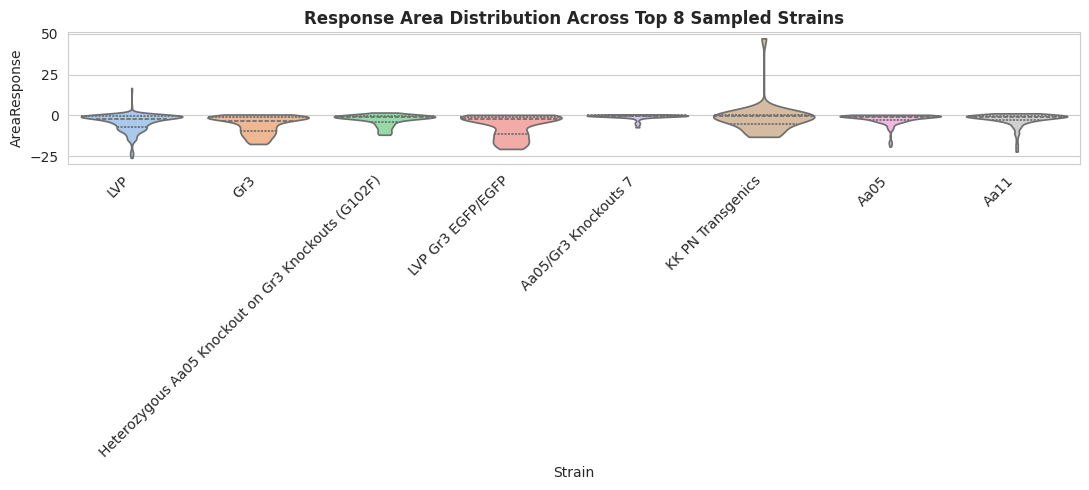

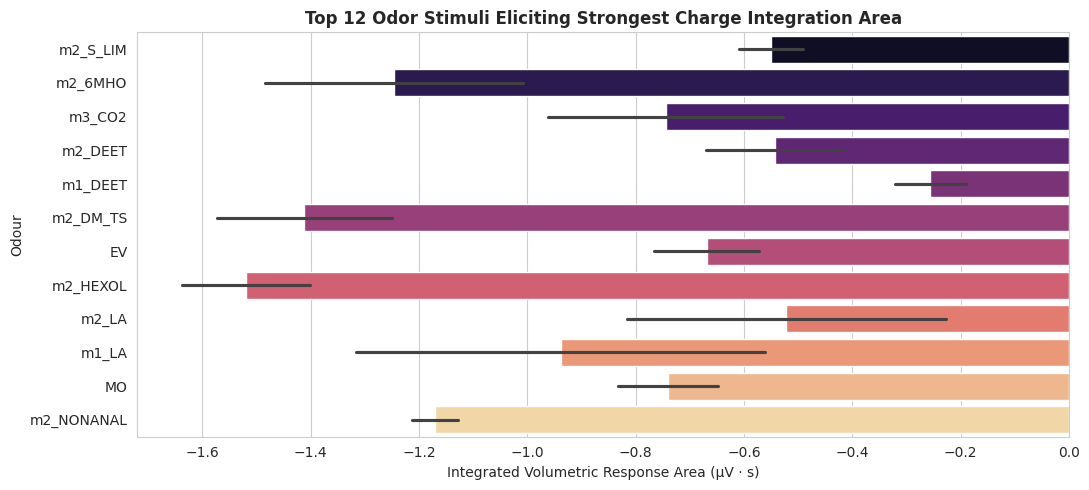


Lineage Specific Integration Capacity Matrix:
                  mean       std  count
Cluster Cell                           
Lateral CpA  -3.149998  4.853197   1036
        CpB  -3.149998  4.853197   1036
        CpC  -3.149998  4.853197   1036
Medial  CpA  -3.987147  5.580531    132
        CpB  -3.987147  5.580531    132
        CpC  -3.987147  5.580531    132


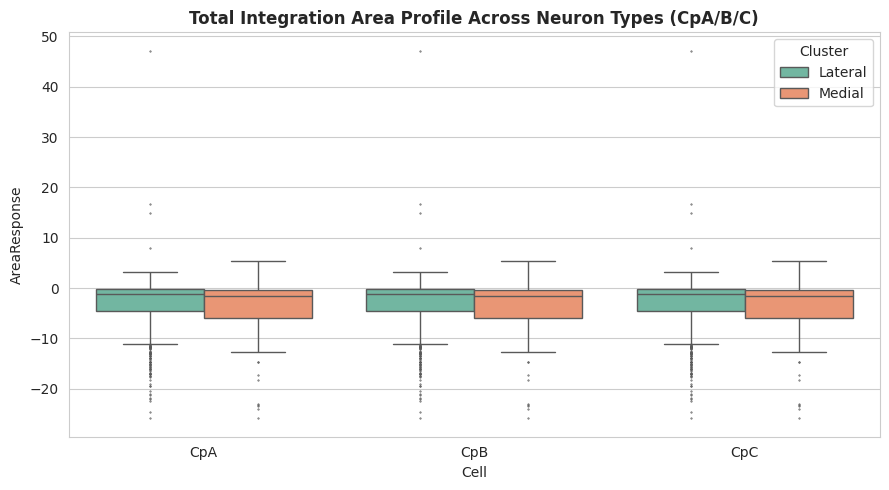

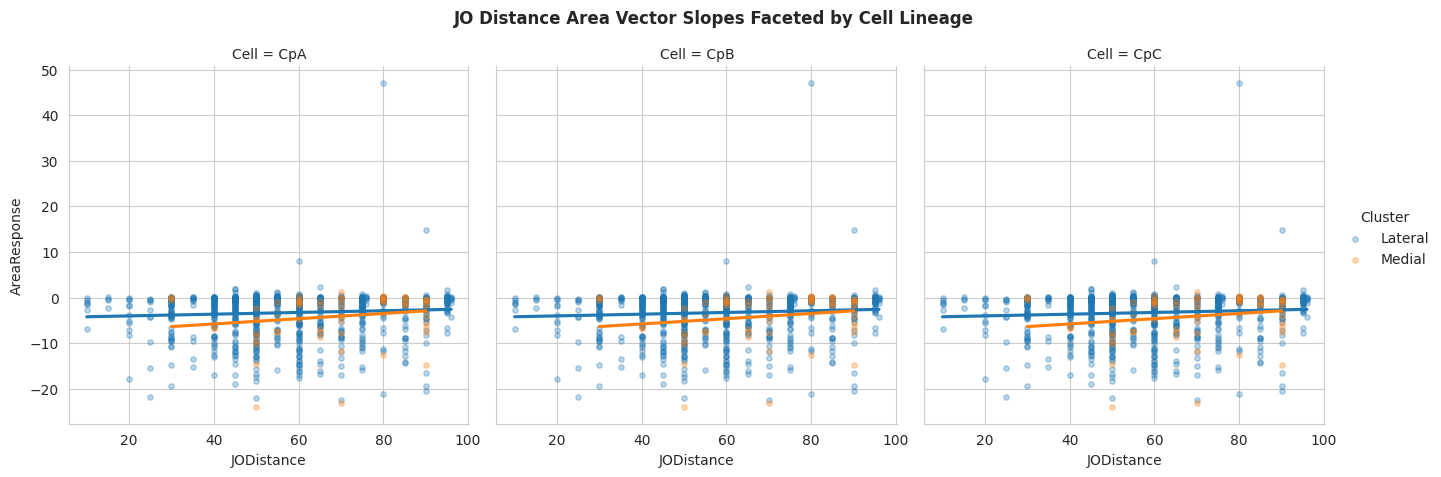

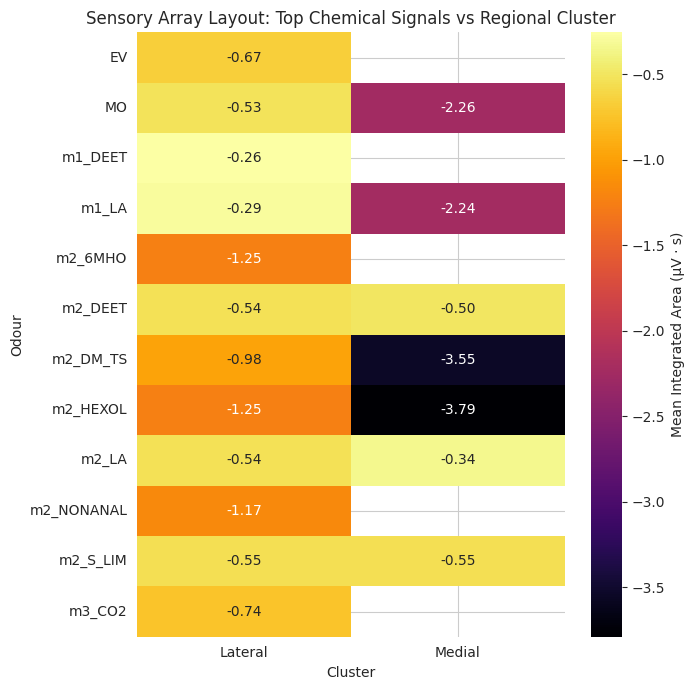


Pipeline Successfully Completed. Long-format data stored under 'area_sensilla_long_tidy.csv'.


In [ ]:
# ==============================================================================
# Mosquito Maxillary Palp Sensilla — Area Spatial Deep Dive (Inclusive)
# ==============================================================================
# Paste this entire script into your Colab cell.
# ==============================================================================

!pip install -q statsmodels openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)

# ----------------------------------------------------------------
# 1. LOAD & RESHAPE DATA (COMPATIBLE WITH EXCEL/CSV)
# ----------------------------------------------------------------
FILE_PATH = "Sensilla_Average_Area_Summary.xlsx - Average_Area.csv"

try:
    df = pd.read_csv(FILE_PATH, header=0)
except Exception:
    df = pd.read_excel("Sensilla_Average_Area_Summary.xlsx", header=0)

meta_cols = ["Strain", "Brain", "Palp", "Sensilla", "Location", "JODistance", "ElectrodeLocation"]
all_response_cols = [c for c in df.columns if c not in meta_cols]

print(f"Raw Matrix Shape: {df.shape}")
print(f"Total Area Columns Found: {len(all_response_cols)}")

# Melt wide matrix format to tidy long format
long_df = df.melt(id_vars=meta_cols, value_vars=all_response_cols,
                  var_name="RawCol", value_name="AreaResponse")

# Extract cell pedigree (CpA, CpB, CpC) and stimulus names
long_df["Cell"] = long_df["RawCol"].str.extract(r"_(Cp[ABC])$")
long_df["Odour"] = long_df["RawCol"].str.replace(r"_Cp[ABC]$", "", regex=True)
long_df = long_df.drop(columns="RawCol").dropna(subset=["AreaResponse"])

print(f"Tidy Long-Format Shape (Recorded responses only): {long_df.shape}")

# ----------------------------------------------------------------
# 2. ANATOMICAL CLUSTERING & SMART INCLUSIVE FILTERS
# ----------------------------------------------------------------
def assign_cluster(loc):
    if pd.isna(loc): return np.nan
    loc = str(loc)
    if "Medial" in loc: return "Medial"
    elif "Lateral" in loc: return "Lateral"
    return np.nan

long_df["Cluster"] = long_df["Location"].apply(assign_cluster)

# INCLUSIVE GEOMETRIC FILTER: Retain rows containing EITHER JODistance OR ElectrodeLocation.
analysis_df = long_df.dropna(subset=["Cluster"]).copy()
analysis_df = analysis_df[analysis_df["JODistance"].notna() | analysis_df["ElectrodeLocation"].notna()]
analysis_df["Strain"] = analysis_df["Strain"].astype(str).str.strip()

# Create unique tracking index per physical hair structure
analysis_df["SensillumID"] = (analysis_df["Strain"] + "|" +
                               analysis_df["Brain"].astype(str) + "|" +
                               analysis_df["Palp"].astype(str) + "|" +
                               analysis_df["Sensilla"].astype(str))

# Export long table asset
analysis_df.to_csv("area_sensilla_long_tidy.csv", index=False)
print(f"Filtered rows usable for spatial mapping (JO or Electrode): {analysis_df.shape[0]}")

# ----------------------------------------------------------------
# 3. SENSILLUM-LEVEL AGGREGATION & BIAS CORRECTION (WEIGHTING)
# ----------------------------------------------------------------
# Collapse multi-odor trial records down to unique physical sensilla coordinates
sensillum_summary = (
    analysis_df.groupby(["SensillumID", "Strain", "Cluster", "JODistance", "ElectrodeLocation"],
                         dropna=False, as_index=False)
    .agg(AvgArea=("AreaResponse", "mean"),
         NReadings=("AreaResponse", "size"))
)
sensillum_summary.to_csv("area_sensillum_level_summary.csv", index=False)

def weighted_pearson(x, y, w):
    """Analytic Weighted Pearson Correlation."""
    x, y, w = np.asarray(x, float), np.asarray(y, float), np.asarray(w, float)
    mx, my = np.average(x, weights=w), np.average(y, weights=w)
    cxy = np.average((x - mx) * (y - my), weights=w)
    cxx = np.average((x - mx) ** 2, weights=w)
    cyy = np.average((y - my) ** 2, weights=w)
    return cxy / np.sqrt(cxx * cyy)

# ==============================================================================
# 4. PRIMARY ANALYTICAL BLOCK: SPATIAL MODELING (AREA VS JO DISTANCE)
# ==============================================================================
print("\n" + "="*80)
print("  PHASE 4: SPATIAL MAPPING — DRIVING INTEGRATION AREA BY JO DISTANCE")
print("="*80)

# Isolate subset explicitly containing valid JO Distances
jo_summary = sensillum_summary.dropna(subset=["JODistance"])

for cluster in ["Medial", "Lateral"]:
    sub = jo_summary[jo_summary["Cluster"] == cluster]
    if len(sub) < 4:
        print(f"\nSkipping {cluster} JO spatial modeling due to limited sample layout.")
        continue

    r_unw, p_unw = stats.pearsonr(sub["JODistance"], sub["AvgArea"])
    r_w = weighted_pearson(sub["JODistance"], sub["AvgArea"], sub["NReadings"])

    print(f"\n>>> {cluster} Cluster JO Profile (n = {len(sub)} Sensilla Hairs) <<<")
    print(f"  Unweighted Pearson r = {r_unw:.3f}, p = {p_unw:.4f}")
    print(f"  Precision Weighted r = {r_w:.3f} (Correcting for sample volume bias)")

    try:
        wls_model = smf.wls("AvgArea ~ JODistance", data=sub, weights=sub["NReadings"]).fit()
        print("\n  Weighted Least Squares (WLS) Linear Fit Summary Table:")
        print(wls_model.summary().tables[1])
    except Exception as e:
        print(f"  WLS Execution Error: {e}")

# Plot 1: Area vs JO Distance (Bubble Plots + LOWESS + Linear Fits)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
for ax, cluster, color in zip(axes, ["Lateral", "Medial"], ["#008080", "#D95F02"]):
    sub = jo_summary[jo_summary["Cluster"] == cluster]
    ax.scatter(sub["JODistance"], sub["AvgArea"], s=sub["NReadings"] * 6, alpha=0.6, color=color, edgecolor="black")
    if len(sub) >= 4:
        wls_model = smf.wls("AvgArea ~ JODistance", data=sub, weights=sub["NReadings"]).fit()
        xs = np.linspace(sub["JODistance"].min(), sub["JODistance"].max(), 100)
        ax.plot(xs, wls_model.predict(pd.DataFrame({"JODistance": xs})), color=color, linewidth=2, label="Linear Slope")
        lowess = sm.nonparametric.lowess(sub["AvgArea"], sub["JODistance"], frac=0.65)
        ax.plot(lowess[:, 0], lowess[:, 1], color="black", linestyle="--", linewidth=1.5, label="LOWESS")
    ax.set_title(f"{cluster} Cluster vs JO Distance (n={len(sub)})")
    ax.set_xlabel("Distance from Johnston's Organ (μm)")
    ax.legend(frameon=True)
axes[0].set_ylabel("Average Response Area (μV · s)")
plt.tight_layout()
plt.savefig("area_vs_jodistance.png", dpi=150)
plt.show()

# ----------------------------------------------------------------
# 4b. SECONDARY GEOMETRIC CHECK: AREA VS ELECTRODE POSITION
# ----------------------------------------------------------------
print("\n" + "="*80)
print("  PHASE 4b: INTEGRATED AREA RESPONSE VS ELECTRODE LOCATION COORDINATES")
print("="*80)

# Isolate subset explicitly containing valid Electrode Position Coordinates
el_summary = sensillum_summary.dropna(subset=["ElectrodeLocation"])

for cluster in ["Medial", "Lateral"]:
    sub = el_summary[el_summary["Cluster"] == cluster]
    if len(sub) < 4:
        print(f"\nSkipping {cluster} electrode position modeling due to limited sample layout.")
        continue

    r_unw, p_unw = stats.pearsonr(sub["ElectrodeLocation"], sub["AvgArea"])
    r_w = weighted_pearson(sub["ElectrodeLocation"], sub["AvgArea"], sub["NReadings"])
    print(f"\n>>> {cluster} Coordinates Vector Evaluation (n = {len(sub)} Sensilla Hairs) <<<")
    print(f"  Unweighted Pearson r = {r_unw:.3f}, p = {p_unw:.4f}")
    print(f"  Precision Weighted r = {r_w:.3f} (Correcting for sample volume bias)")
    try:
        wls_el = smf.wls("AvgArea ~ ElectrodeLocation", data=sub, weights=sub["NReadings"]).fit()
        print("\n  Weighted Least Squares (WLS) Linear Fit Summary Table:")
        print(wls_el.summary().tables[1])
    except Exception as e: print(f"WLS coordinate evaluation faulted: {e}")

# Plot 2: Area vs Electrode Location
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
for ax, cluster, color in zip(axes, ["Lateral", "Medial"], ["#4a90e2", "#e67e22"]):
    sub = el_summary[el_summary["Cluster"] == cluster]
    ax.scatter(sub["ElectrodeLocation"], sub["AvgArea"], s=sub["NReadings"] * 6, alpha=0.6, color=color, edgecolor="black")
    if len(sub) >= 4:
        wls_model = smf.wls("AvgArea ~ ElectrodeLocation", data=sub, weights=sub["NReadings"]).fit()
        xs = np.linspace(sub["ElectrodeLocation"].min(), sub["ElectrodeLocation"].max(), 100)
        ax.plot(xs, wls_model.predict(pd.DataFrame({"ElectrodeLocation": xs})), color=color, linewidth=2, label="Linear Slope")
        lowess = sm.nonparametric.lowess(sub["AvgArea"], sub["ElectrodeLocation"], frac=0.65)
        ax.plot(lowess[:, 0], lowess[:, 1], color="black", linestyle="--", linewidth=1.5, label="LOWESS")
    ax.set_title(f"{cluster} Cluster vs Electrode Position (n={len(sub)})")
    ax.set_xlabel("Electrode Mapping Coordinate (μm)")
    ax.legend(frameon=True)
axes[0].set_ylabel("Average Response Area (μV · s)")
plt.tight_layout()
plt.savefig("area_vs_electrodelocation.png", dpi=150)
plt.show()

# ----------------------------------------------------------------
# 4c. COARSE AREA DISTRIBUTION VARIATION OVER SPATIAL SECTORS
# ----------------------------------------------------------------
jo_analysis_df = analysis_df.dropna(subset=["JODistance"]).copy()
jo_analysis_df["JODistanceBin"] = pd.cut(jo_analysis_df["JODistance"], bins=4)

# Plot 3: Boxplots over discretized distance bins
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, cluster in zip(axes, ["Lateral", "Medial"]):
    sub = jo_analysis_df[jo_analysis_df["Cluster"] == cluster]
    sns.boxplot(data=sub, x="JODistanceBin", y="AreaResponse", ax=ax, palette="flare", fliersize=1)
    ax.set_title(f"{cluster} Integrated Area Range Over Distance Bins")
    ax.set_xlabel("JO Distance Bands (μm)")
    ax.tick_params(axis="x", rotation=20)
axes[0].set_ylabel("Trial Area Responses (μV · s)")
plt.tight_layout()
plt.savefig("area_variance_brackets.png", dpi=150)
plt.show()

# ==============================================================================
# 5. ADVANCED QUANTITATIVE INFERENCE: LINEAR MIXED MODELS
# ==============================================================================
print("\n" + "="*80)
print("  PHASE 5: INDUCTIVE COVARIANCES — LINEAR MIXED MODELS")
print("="*80)

for cluster in ["Medial", "Lateral"]:
    sub = analysis_df[analysis_df["Cluster"] == cluster].copy()
    sub_jo = sub.dropna(subset=["JODistance"])
    if sub_jo["Strain"].nunique() < 2 or len(sub_jo) < 15:
        print(f"\nSkipping LMM analysis for {cluster} due to insufficient strain groupings.")
        continue

    print(f"\n[LMM Output] {cluster} Array: Area ~ JODistance + Cell Lineage (Random Intercepts: Strain)")
    try:
        model = smf.mixedlm("AreaResponse ~ JODistance + Cell", data=sub_jo, groups=sub_jo["Strain"])
        print(model.fit(reml=True).summary().tables[1])
    except Exception as e: print(f"LMM Convergence Failed: {e}")

print("\n[Anatomical Interaction Matrix] Evaluating Spatial Slope Divergence between Clusters:")
try:
    inter_model = smf.mixedlm("AreaResponse ~ JODistance * Cluster", data=jo_analysis_df, groups=jo_analysis_df["Strain"])
    print(inter_model.fit(reml=True).summary())
except Exception as e: print(f"Structural cross interaction model failed: {e}")

# ==============================================================================
# 6. SECONDARY MULTI-DIMENSIONAL SCREENING & EXTENSIVE VISUALIZATION
# ==============================================================================
print("\n" + "="*80)
print("  PHASE 6: RECEPTOR METRICS SUMMARY (ODOR SPECTRA AND PHENOTYPES)")
print("="*80)

# --- 6a. Phenotypic Range by Strain (Plot 4) ---
strain_summary = analysis_df.groupby("Strain")["AreaResponse"].agg(["mean", "std", "count"]).sort_values("count", ascending=False)
print("\nTop Evaluated Mosquito Strain Lineages:")
print(strain_summary.head(8))

plt.figure(figsize=(11, 5))
top_strains = strain_summary.head(8).index
sns.violinplot(data=analysis_df[analysis_df["Strain"].isin(top_strains)], x="Strain", y="AreaResponse", cut=0, inner="quartile", palette="pastel")
plt.xticks(rotation=45, ha="right")
plt.title("Response Area Distribution Across Top 8 Sampled Strains", weight='bold')
plt.tight_layout()
plt.savefig("area_distribution_by_strain.png", dpi=150)
plt.show()

# --- 6b. Functional Odor Characterization (Plot 5) ---
odour_summary = analysis_df.groupby("Odour")["AreaResponse"].agg(["mean", "std", "count"])
top_odours = odour_summary[odour_summary["count"] >= 5].sort_values("mean", ascending=False).head(12).index

plt.figure(figsize=(11, 5))
sns.barplot(data=analysis_df[analysis_df["Odour"].isin(top_odours)], y="Odour", x="AreaResponse", errorbar="se", palette="magma")
plt.title("Top 12 Odor Stimuli Eliciting Strongest Charge Integration Area", weight='bold')
plt.xlabel("Integrated Volumetric Response Area (μV · s)")
plt.tight_layout()
plt.savefig("area_top_odors_profile.png", dpi=150)
plt.show()

# --- 6c. Lineage Profiles (CpA, B, C Sub-units) (Plot 6) ---
print("\nLineage Specific Integration Capacity Matrix:")
print(analysis_df.groupby(["Cluster", "Cell"])["AreaResponse"].agg(["mean", "std", "count"]))

plt.figure(figsize=(9, 5))
sns.boxplot(data=analysis_df, x="Cell", y="AreaResponse", hue="Cluster", palette="Set2", fliersize=0.5)
plt.title("Total Integration Area Profile Across Neuron Types (CpA/B/C)", weight='bold')
plt.tight_layout()
plt.savefig("area_by_cell_type.png", dpi=150)
plt.show()

# --- 6d. Spatial Divergence across Cell Lineages (Plot 7) ---
g = sns.lmplot(data=jo_analysis_df, x="JODistance", y="AreaResponse", col="Cell", hue="Cluster", height=4.5, aspect=1, scatter_kws={"alpha": 0.3, "s": 15}, ci=None)
g.fig.suptitle("JO Distance Area Vector Slopes Faceted by Cell Lineage", y=1.05, weight='bold')
plt.savefig("area_distance_by_cell_facet.png", dpi=150, bbox_inches="tight")
plt.show()

# --- 6e. Spatial Receptor Distribution Maps (Heatmaps) (Plot 8) ---
pivot = analysis_df[analysis_df["Odour"].isin(top_odours)].groupby(["Odour", "Cluster"])["AreaResponse"].mean().unstack()
plt.figure(figsize=(7, 7))
sns.heatmap(pivot, cmap="inferno", annot=True, fmt=".2f", cbar_kws={'label': 'Mean Integrated Area (μV · s)'})
plt.title("Sensory Array Layout: Top Chemical Signals vs Regional Cluster")
plt.tight_layout()
plt.savefig("area_spatial_odor_heatmap.png", dpi=150)
plt.show()

print("\n" + "="*80)
print("Pipeline Successfully Completed. Long-format data stored under 'area_sensilla_long_tidy.csv'.")
print("="*80)